
=== Final Results ===

--- Original ---
Test b1: F1-Score = 0.0327, Std = 0.0068
Test b2: F1-Score = 0.0276, Std = 0.0018
Test b3: F1-Score = 0.0432, Std = 0.0029
Test b4: F1-Score = 0.1020, Std = 0.0138
Test b5: F1-Score = 0.1750, Std = 0.0186
Test b6: F1-Score = 0.2497, Std = 0.0169
Test b7: F1-Score = 0.3162, Std = 0.0240
Test b8: F1-Score = 0.3702, Std = 0.0133
Test b9: F1-Score = 0.3959, Std = 0.0099
Test b10: F1-Score = 0.4222, Std = 0.0099
Test b11: F1-Score = 0.4358, Std = 0.0068
Test b12: F1-Score = 0.4442, Std = 0.0103
Test b13: F1-Score = 0.4489, Std = 0.0119
Test b14: F1-Score = 0.4508, Std = 0.0153
Test b15: F1-Score = 0.4516, Std = 0.0179
Test b16: F1-Score = 0.4536, Std = 0.0192
Test b17: F1-Score = 0.4591, Std = 0.0214
Test b18: F1-Score = 0.4620, Std = 0.0204
Test b19: F1-Score = 0.4616, Std = 0.0203
Test b20: F1-Score = 0.4624, Std = 0.0202
Test b21: F1-Score = 0.4623, Std = 0.0208
Test b22: F1-Score = 0.4622, Std = 0.0206
Test b23: F1-Score = 0.4623, Std = 0.0208
Te

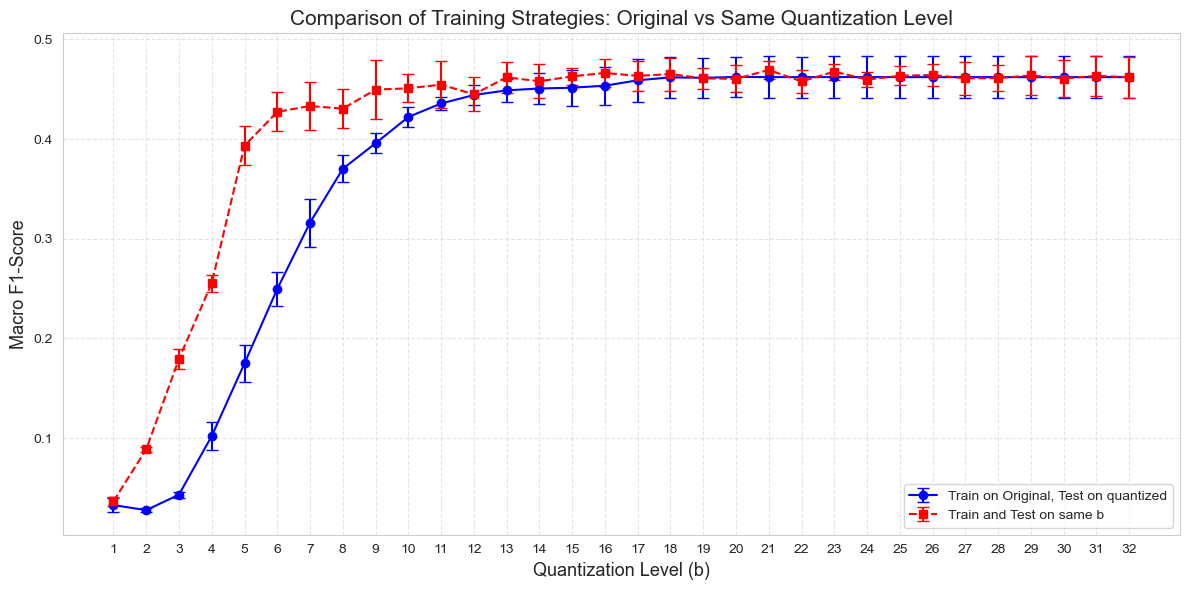

In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
quantized_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")

file_name = "Topology_A_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)

df_original = pd.read_csv(input_file_path)
X_original = df_original.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = df_original["Device Name"].astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

b_values = list(range(1, 33))
quantized_paths = {f"b{b}": os.path.join(quantized_folder, f"Topology_A_fix_duration_value_b{b}.csv") for b in b_values}

train_sources = {
    "Original": input_file_path,
    "Same b": None
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_matrix = {train_name: {f"b{b}": [] for b in b_values} for train_name in train_sources}

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_original, y_original)):
    df_train = pd.read_csv(train_sources["Original"])
    X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
    y_train = df_train["Device Name"].astype("category")
    y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
    rf_model.fit(X_train, y_train)

    for b in b_values:
        test_path = quantized_paths[f"b{b}"]
        df_test = pd.read_csv(test_path)
        X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
        y_test = df_test["Device Name"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

        y_pred = rf_model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        f1_matrix["Original"][f"b{b}"].append(f1)

    for b in b_values:
        train_path = quantized_paths[f"b{b}"]
        df_train = pd.read_csv(train_path)
        X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
        y_train = df_train["Device Name"].astype("category")
        y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

        class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
        rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
        rf_model.fit(X_train, y_train)

        test_path = quantized_paths[f"b{b}"]
        df_test = pd.read_csv(test_path)
        X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
        y_test = df_test["Device Name"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

        y_pred = rf_model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        f1_matrix["Same b"][f"b{b}"].append(f1)

mean_f1_matrix = {train_name: [np.mean(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}
std_f1_matrix = {train_name: [np.std(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}

plt.figure(figsize=(12, 6))

plt.errorbar(
    b_values,
    mean_f1_matrix["Original"],
    yerr=std_f1_matrix["Original"],
    label="Train on Original, Test on quantized",
    capsize=4,
    marker='o',
    linestyle='-',
    color='blue'
)

plt.errorbar(
    b_values,
    mean_f1_matrix["Same b"],
    yerr=std_f1_matrix["Same b"],
    label="Train and Test on same b",
    capsize=4,
    marker='s',
    linestyle='--',
    color='red'
)

print("\n=== Final Results ===")
for train_name in mean_f1_matrix:
    print(f"\n--- {train_name} ---")
    for b, mean_acc in zip(b_values, mean_f1_matrix[train_name]):
        std = std_f1_matrix[train_name][b - 1]
        print(f"Test b{b}: F1-Score = {mean_acc:.4f}, Std = {std:.4f}")

plt.title("Comparison of Training Strategies: Original vs Same Quantization Level", fontsize=15)
plt.xlabel("Quantization Level (b)", fontsize=13)
plt.ylabel("Macro F1-Score", fontsize=13)
plt.xticks(b_values)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


=== Final Results ===

--- Original ---
Test b1: F1-Score = 0.0211, Std = 0.0027
Test b2: F1-Score = 0.0317, Std = 0.0054
Test b3: F1-Score = 0.0547, Std = 0.0031
Test b4: F1-Score = 0.0866, Std = 0.0057
Test b5: F1-Score = 0.1052, Std = 0.0083
Test b6: F1-Score = 0.2295, Std = 0.0241
Test b7: F1-Score = 0.2784, Std = 0.0299
Test b8: F1-Score = 0.3273, Std = 0.0265
Test b9: F1-Score = 0.3446, Std = 0.0268
Test b10: F1-Score = 0.3774, Std = 0.0197
Test b11: F1-Score = 0.3819, Std = 0.0210
Test b12: F1-Score = 0.3913, Std = 0.0166
Test b13: F1-Score = 0.3993, Std = 0.0112
Test b14: F1-Score = 0.4027, Std = 0.0100
Test b15: F1-Score = 0.4059, Std = 0.0130
Test b16: F1-Score = 0.4110, Std = 0.0125
Test b17: F1-Score = 0.4112, Std = 0.0127
Test b18: F1-Score = 0.4122, Std = 0.0131
Test b19: F1-Score = 0.4117, Std = 0.0133
Test b20: F1-Score = 0.4117, Std = 0.0133
Test b21: F1-Score = 0.4118, Std = 0.0133
Test b22: F1-Score = 0.4120, Std = 0.0133
Test b23: F1-Score = 0.4120, Std = 0.0131
Te

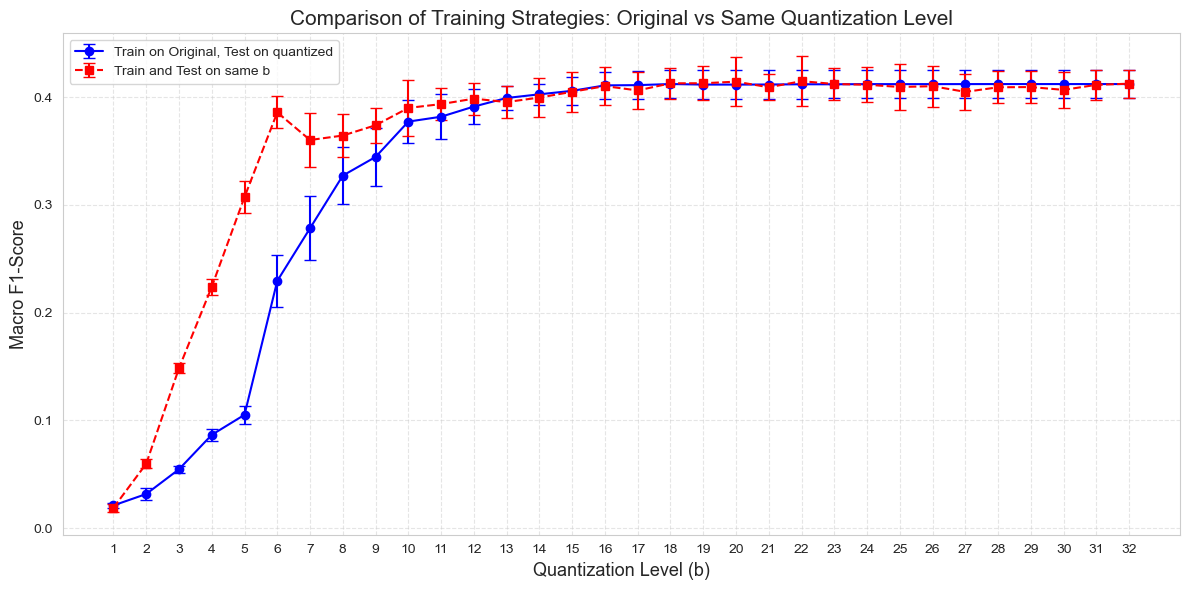

In [2]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_durations")
quantized_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_durations", "Quantized_values")

file_name = "Topology_B_fix_duration.csv"
input_file_path = os.path.join(input_folder, file_name)

df_original = pd.read_csv(input_file_path)
X_original = df_original.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = df_original["Device Name"].astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

b_values = list(range(1, 33))
quantized_paths = {f"b{b}": os.path.join(quantized_folder, f"Topology_B_fix_duration_value_b{b}.csv") for b in b_values}

train_sources = {
    "Original": input_file_path,
    "Same b": None
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_matrix = {train_name: {f"b{b}": [] for b in b_values} for train_name in train_sources}

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_original, y_original)):
    df_train = pd.read_csv(train_sources["Original"])
    X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
    y_train = df_train["Device Name"].astype("category")
    y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
    rf_model.fit(X_train, y_train)

    for b in b_values:
        test_path = quantized_paths[f"b{b}"]
        df_test = pd.read_csv(test_path)
        X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
        y_test = df_test["Device Name"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

        y_pred = rf_model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        f1_matrix["Original"][f"b{b}"].append(f1)

    for b in b_values:
        train_path = quantized_paths[f"b{b}"]
        df_train = pd.read_csv(train_path)
        X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
        y_train = df_train["Device Name"].astype("category")
        y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

        class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
        rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
        rf_model.fit(X_train, y_train)

        test_path = quantized_paths[f"b{b}"]
        df_test = pd.read_csv(test_path)
        X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
        y_test = df_test["Device Name"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

        y_pred = rf_model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        f1_matrix["Same b"][f"b{b}"].append(f1)

mean_f1_matrix = {train_name: [np.mean(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}
std_f1_matrix = {train_name: [np.std(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}

plt.figure(figsize=(12, 6))

plt.errorbar(
    b_values,
    mean_f1_matrix["Original"],
    yerr=std_f1_matrix["Original"],
    label="Train on Original, Test on quantized",
    capsize=4,
    marker='o',
    linestyle='-',
    color='blue'
)

plt.errorbar(
    b_values,
    mean_f1_matrix["Same b"],
    yerr=std_f1_matrix["Same b"],
    label="Train and Test on same b",
    capsize=4,
    marker='s',
    linestyle='--',
    color='red'
)

print("\n=== Final Results ===")
for train_name in mean_f1_matrix:
    print(f"\n--- {train_name} ---")
    for b, mean_acc in zip(b_values, mean_f1_matrix[train_name]):
        std = std_f1_matrix[train_name][b - 1]
        print(f"Test b{b}: F1-Score = {mean_acc:.4f}, Std = {std:.4f}")

plt.title("Comparison of Training Strategies: Original vs Same Quantization Level", fontsize=15)
plt.xlabel("Quantization Level (b)", fontsize=13)
plt.ylabel("Macro F1-Score", fontsize=13)
plt.xticks(b_values)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

D:\Anaconda\envs\compression\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(



=== Final Results ===

--- Original ---
Test b1: F1-Score = 0.0245, Std = 0.0023
Test b2: F1-Score = 0.0485, Std = 0.0080
Test b3: F1-Score = 0.0685, Std = 0.0194
Test b4: F1-Score = 0.1233, Std = 0.0231
Test b5: F1-Score = 0.1971, Std = 0.0219
Test b6: F1-Score = 0.3005, Std = 0.0215
Test b7: F1-Score = 0.4509, Std = 0.0345
Test b8: F1-Score = 0.5172, Std = 0.0367
Test b9: F1-Score = 0.5775, Std = 0.0388
Test b10: F1-Score = 0.6196, Std = 0.0430
Test b11: F1-Score = 0.6623, Std = 0.0323
Test b12: F1-Score = 0.7211, Std = 0.0367
Test b13: F1-Score = 0.7507, Std = 0.0310
Test b14: F1-Score = 0.7653, Std = 0.0323
Test b15: F1-Score = 0.7832, Std = 0.0338
Test b16: F1-Score = 0.7899, Std = 0.0350
Test b17: F1-Score = 0.7943, Std = 0.0343
Test b18: F1-Score = 0.7957, Std = 0.0343
Test b19: F1-Score = 0.7972, Std = 0.0352
Test b20: F1-Score = 0.7971, Std = 0.0353
Test b21: F1-Score = 0.7972, Std = 0.0352
Test b22: F1-Score = 0.7973, Std = 0.0351
Test b23: F1-Score = 0.7974, Std = 0.0351
Te

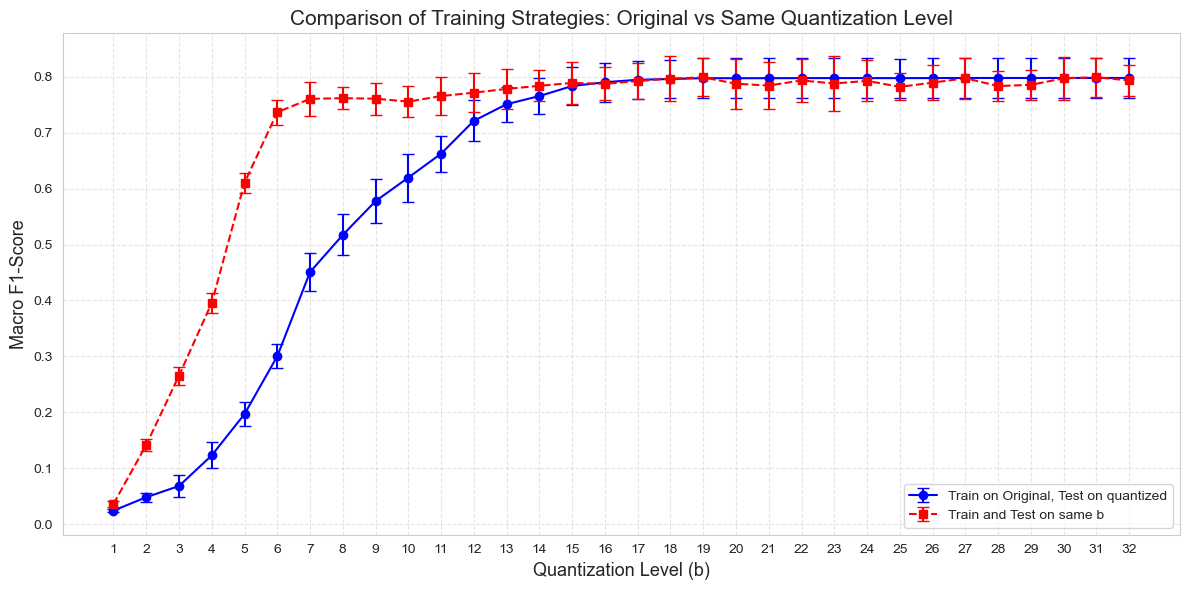

In [3]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_packets")
quantized_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_packets", "Quantized_values")

file_name = "Topology_A_fix_packets.csv"
input_file_path = os.path.join(input_folder, file_name)

df_original = pd.read_csv(input_file_path)
X_original = df_original.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = df_original["Device Name"].astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

b_values = list(range(1, 33))
quantized_paths = {f"b{b}": os.path.join(quantized_folder, f"Topology_A_fix_packets_value_b{b}.csv") for b in b_values}

train_sources = {
    "Original": input_file_path,
    "Same b": None
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_matrix = {train_name: {f"b{b}": [] for b in b_values} for train_name in train_sources}

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_original, y_original)):
    df_train = pd.read_csv(train_sources["Original"])
    X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
    y_train = df_train["Device Name"].astype("category")
    y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
    rf_model.fit(X_train, y_train)

    for b in b_values:
        test_path = quantized_paths[f"b{b}"]
        df_test = pd.read_csv(test_path)
        X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
        y_test = df_test["Device Name"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

        y_pred = rf_model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        f1_matrix["Original"][f"b{b}"].append(f1)

    for b in b_values:
        train_path = quantized_paths[f"b{b}"]
        df_train = pd.read_csv(train_path)
        X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
        y_train = df_train["Device Name"].astype("category")
        y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

        class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
        rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
        rf_model.fit(X_train, y_train)

        test_path = quantized_paths[f"b{b}"]
        df_test = pd.read_csv(test_path)
        X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
        y_test = df_test["Device Name"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

        y_pred = rf_model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        f1_matrix["Same b"][f"b{b}"].append(f1)

mean_f1_matrix = {train_name: [np.mean(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}
std_f1_matrix = {train_name: [np.std(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}

plt.figure(figsize=(12, 6))

plt.errorbar(
    b_values,
    mean_f1_matrix["Original"],
    yerr=std_f1_matrix["Original"],
    label="Train on Original, Test on quantized",
    capsize=4,
    marker='o',
    linestyle='-',
    color='blue'
)

plt.errorbar(
    b_values,
    mean_f1_matrix["Same b"],
    yerr=std_f1_matrix["Same b"],
    label="Train and Test on same b",
    capsize=4,
    marker='s',
    linestyle='--',
    color='red'
)

print("\n=== Final Results ===")
for train_name in mean_f1_matrix:
    print(f"\n--- {train_name} ---")
    for b, mean_acc in zip(b_values, mean_f1_matrix[train_name]):
        std = std_f1_matrix[train_name][b - 1]
        print(f"Test b{b}: F1-Score = {mean_acc:.4f}, Std = {std:.4f}")

plt.title("Comparison of Training Strategies: Original vs Same Quantization Level", fontsize=15)
plt.xlabel("Quantization Level (b)", fontsize=13)
plt.ylabel("Macro F1-Score", fontsize=13)
plt.xticks(b_values)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


=== Final Results ===

--- Original ---
Test b1: F1-Score = 0.0248, Std = 0.0022
Test b2: F1-Score = 0.0364, Std = 0.0034
Test b3: F1-Score = 0.1093, Std = 0.0106
Test b4: F1-Score = 0.1645, Std = 0.0110
Test b5: F1-Score = 0.2316, Std = 0.0107
Test b6: F1-Score = 0.3420, Std = 0.0265
Test b7: F1-Score = 0.4685, Std = 0.0314
Test b8: F1-Score = 0.5911, Std = 0.0206
Test b9: F1-Score = 0.6669, Std = 0.0300
Test b10: F1-Score = 0.7193, Std = 0.0305
Test b11: F1-Score = 0.7425, Std = 0.0253
Test b12: F1-Score = 0.7507, Std = 0.0233
Test b13: F1-Score = 0.7773, Std = 0.0195
Test b14: F1-Score = 0.7873, Std = 0.0192
Test b15: F1-Score = 0.7928, Std = 0.0173
Test b16: F1-Score = 0.8071, Std = 0.0185
Test b17: F1-Score = 0.8114, Std = 0.0180
Test b18: F1-Score = 0.8126, Std = 0.0179
Test b19: F1-Score = 0.8132, Std = 0.0178
Test b20: F1-Score = 0.8142, Std = 0.0184
Test b21: F1-Score = 0.8150, Std = 0.0179
Test b22: F1-Score = 0.8151, Std = 0.0179
Test b23: F1-Score = 0.8151, Std = 0.0179
Te

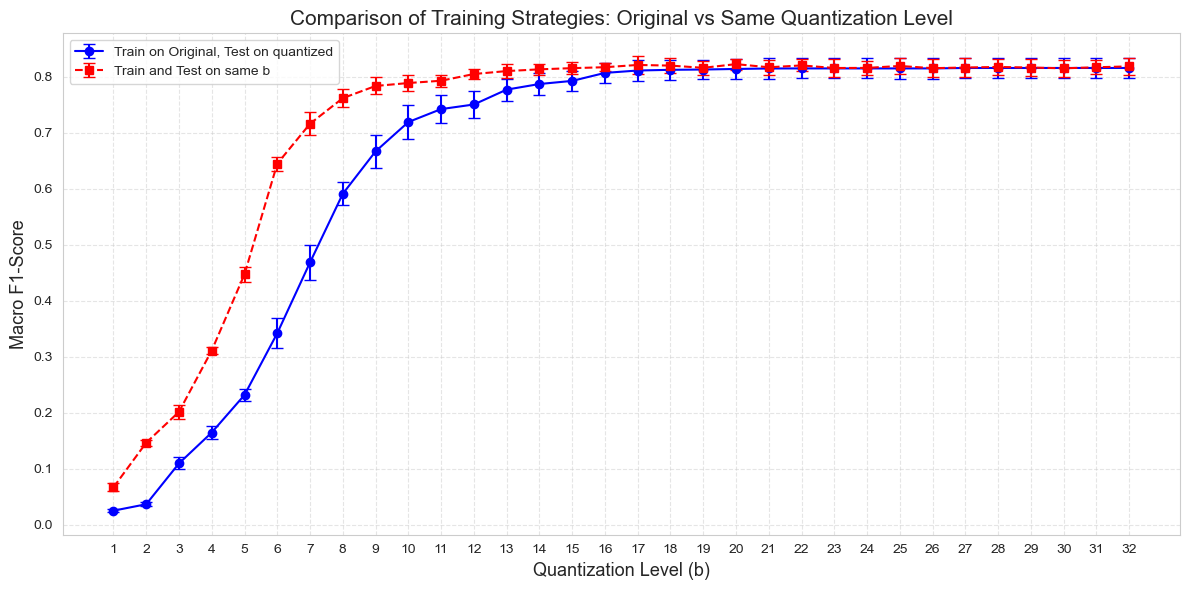

In [4]:
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

base_dir = "D:/ZBIOT-2025/Dataset"
input_folder = os.path.join(base_dir, "Merged_Data", "A_6-Merged_sequence_data_fix_packets")
quantized_folder = os.path.join(base_dir, "Quantized_Data", "A_6-Merged_sequence_data_fix_packets", "Quantized_values")

file_name = "Topology_B_fix_packets.csv"
input_file_path = os.path.join(input_folder, file_name)

df_original = pd.read_csv(input_file_path)
X_original = df_original.drop(columns=["Device Name", "Device Type", "File Name"])
y_original = df_original["Device Name"].astype("category")
categories = y_original.cat.categories
y_original = y_original.cat.codes

b_values = list(range(1, 33))
quantized_paths = {f"b{b}": os.path.join(quantized_folder, f"Topology_B_fix_packets_value_b{b}.csv") for b in b_values}

train_sources = {
    "Original": input_file_path,
    "Same b": None
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_matrix = {train_name: {f"b{b}": [] for b in b_values} for train_name in train_sources}

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_original, y_original)):
    df_train = pd.read_csv(train_sources["Original"])
    X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
    y_train = df_train["Device Name"].astype("category")
    y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

    class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
    rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
    rf_model.fit(X_train, y_train)

    for b in b_values:
        test_path = quantized_paths[f"b{b}"]
        df_test = pd.read_csv(test_path)
        X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
        y_test = df_test["Device Name"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

        y_pred = rf_model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        f1_matrix["Original"][f"b{b}"].append(f1)

    for b in b_values:
        train_path = quantized_paths[f"b{b}"]
        df_train = pd.read_csv(train_path)
        X_train = df_train.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[train_idx]
        y_train = df_train["Device Name"].astype("category")
        y_train = y_train.cat.set_categories(categories).cat.codes.iloc[train_idx]

        class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
        rf_model = RandomForestClassifier(random_state=42, class_weight={i: w for i, w in enumerate(class_weights)})
        rf_model.fit(X_train, y_train)

        test_path = quantized_paths[f"b{b}"]
        df_test = pd.read_csv(test_path)
        X_test = df_test.drop(columns=["Device Name", "Device Type", "File Name"]).iloc[test_idx]
        y_test = df_test["Device Name"].astype("category").cat.set_categories(categories).cat.codes.iloc[test_idx]

        y_pred = rf_model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        f1_matrix["Same b"][f"b{b}"].append(f1)

mean_f1_matrix = {train_name: [np.mean(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}
std_f1_matrix = {train_name: [np.std(f1_matrix[train_name][f"b{b}"]) for b in b_values] for train_name in f1_matrix}

plt.figure(figsize=(12, 6))

plt.errorbar(
    b_values,
    mean_f1_matrix["Original"],
    yerr=std_f1_matrix["Original"],
    label="Train on Original, Test on quantized",
    capsize=4,
    marker='o',
    linestyle='-',
    color='blue'
)

plt.errorbar(
    b_values,
    mean_f1_matrix["Same b"],
    yerr=std_f1_matrix["Same b"],
    label="Train and Test on same b",
    capsize=4,
    marker='s',
    linestyle='--',
    color='red'
)

print("\n=== Final Results ===")
for train_name in mean_f1_matrix:
    print(f"\n--- {train_name} ---")
    for b, mean_acc in zip(b_values, mean_f1_matrix[train_name]):
        std = std_f1_matrix[train_name][b - 1]
        print(f"Test b{b}: F1-Score = {mean_acc:.4f}, Std = {std:.4f}")

plt.title("Comparison of Training Strategies: Original vs Same Quantization Level", fontsize=15)
plt.xlabel("Quantization Level (b)", fontsize=13)
plt.ylabel("Macro F1-Score", fontsize=13)
plt.xticks(b_values)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()